In [1]:
# import libraries
from cil.optimisation.functions import TotalVariation, L2NormSquared
from cil.framework import ImageGeometry
from cil.utilities.dataexample import TestData
from cil.utilities.display import plotter2D

from skimage import data
from skimage.color import rgb2gray

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load chelsea image from skimage
image = data.astronaut().astype("float32")/255.0

In [3]:
# Setup the image domain and fill the image into an ImageData
ig = ImageGeometry(voxel_num_y=image.shape[1], voxel_num_x=image.shape[0], channels=image.shape[2],
                  dimension_labels=['horizontal_x', 'horizontal_y', 'channel'])
data = ig.allocate()
data.fill(image)

In [4]:
# Add gaussian noise
noisy_data = TestData.random_noise(data, mode = 'gaussian', seed = 10, var = 0.005)

In [5]:
# Regularisation parameter for the Total variation term
alpha = 0.1
TV = alpha * TotalVariation(max_iteration=100)

# Run proximal operator for the TotalVariation
proxTV = TV.proximal(noisy_data, tau=1.0)

/opt/anaconda3/envs/CIL2_submit/lib/python3.7/site-packages/cil/optimisation/operators/GradientOperator.py:85: UserWarning: Warning: correlation='Space' on multi-channel dataset will use `numpy` backend
  warnings.warn("Warning: correlation='Space' on multi-channel dataset will use `numpy` backend")


Initialised GradientOperator with numpy backend


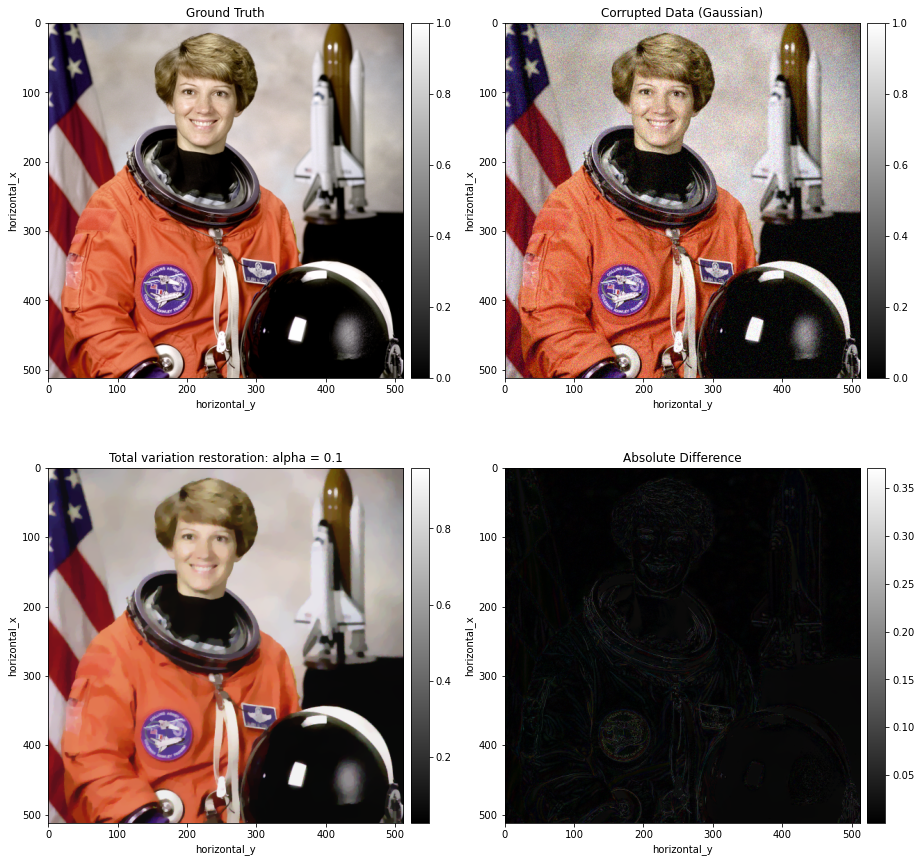

In [6]:
plotter2D([data, noisy_data, proxTV, (proxTV-data).abs()],
          titles=["Ground Truth", 
                  "Corrupted Data (Gaussian)", 
                  "Total variation restoration: alpha = {}".format(alpha),
                  "Absolute Difference"],
         origin = "upper")

# When TV.proximal is called, we solve in fact the dual problem of the total variation denoising:



In [39]:
# add spacing propert in BlockGeometry

from cil.framework import BlockGeometry

@property
def spacing(self):
    
    geom_info=[]
    for i in self.geometries:

        spacing_dict = {ImageGeometry.CHANNEL: i.channel_spacing,
                        ImageGeometry.VERTICAL: i.voxel_size_z,
                        ImageGeometry.HORIZONTAL_Y: i.voxel_size_y,        
                        ImageGeometry.HORIZONTAL_X: i.voxel_size_x}

        spacing = []
        for label in i.dimension_labels:
            spacing.append(spacing_dict[label])
            
        geom_info.append(spacing)    

    return tuple(geom_info)

setattr(BlockGeometry, "spacing", spacing)

In [48]:
BG.geometries[0]

Initialised GradientOperator with numpy backend


AttributeError: 'BlockGeometry' object has no attribute 'channels'

In [22]:
conjF

<bound method ScaledFunction.convex_conjugate of <cil.optimisation.functions.Function.ScaledFunction object at 0x7f9998c812d0>>

In [78]:
class Divergence2D(LinearOperator):
    
    def __init__(self, domain_geometry, method="forward", bnd_cond="Neumann"):
        
        self.size_dom_gm = len(domain_geometry.shape)               
        self.bnd_cond = bnd_cond 
        
        # Call FiniteDiff operator 
        self.method = method                        
        self.FD = FiniteDifferenceOperator(domain_geometry.geometries[0], direction = 0, method = self.method, bnd_cond = self.bnd_cond)
                    
        if domain_geometry.geometries[0].channels > 1:

            range_geometry = BlockGeometry(*[domain_geometry.geometries[0] for _ in range(domain_geometry.geometries[0].length-1)] )

            if self.size_dom_gm == 4:
                # 3D + Channel
                expected_order = [ImageGeometry.CHANNEL, ImageGeometry.VERTICAL, ImageGeometry.HORIZONTAL_Y, ImageGeometry.HORIZONTAL_X]

            else:
                # 2D + Channel
                expected_order = [ImageGeometry.CHANNEL, ImageGeometry.HORIZONTAL_Y, ImageGeometry.HORIZONTAL_X]

            order = domain_geometry.geometries[0].get_order_by_label(domain_geometry.geometries[0].dimension_labels, expected_order)

            self.ind = order[1:]        
        
        self.voxel_size_order = domain_geometry.geometries[0].spacing 
        super(Divergence2D, self).__init__(domain_geometry = domain_geometry, 
                                     range_geometry = domain_geometry.geometries[0]) 

    def direct(self, x, out=None):

        if out is not None:

            tmp = self.range_geometry().allocate()            
            for i in range(x.shape[0]):
                self.FD.direction=self.ind[i] 
                self.FD.voxel_size = self.voxel_size_order[i]
                self.FD.adjoint(x.get_item(i), out = tmp)
                if i == 0:
                    out.fill(tmp)
                else:
                    out += tmp
        else:            
            tmp = self.range_geometry().allocate()
            for i in range(x.shape[0]):
                self.FD.direction=self.ind[i]
                self.FD.voxel_size = self.voxel_size_order[i]
                tmp += self.FD.adjoint(x.get_item(i))
            return tmp 
        
    def adjoint(self, x, out=None):        
                
         if out is not None:
            
             for i in range(self.domain_geometry().shape[0]):
                 self.FD.direction = self.ind[i]
                 self.FD.voxel_size = self.voxel_size_order[i]
                 self.FD.direct(x, out = out[i])
         else:
             tmp = self.domain_geometry().allocate()        
             for i in range(tmp.shape[0]):
                 self.FD.direction = self.ind[i]
                 self.FD.voxel_size = self.voxel_size_order[i]
                 tmp.get_item(i).fill(self.FD.direct(x))
             return tmp         
                
        
# Grad = GradientOperator(ig)    
# x = ig.allocate('random')
# res = Grad.direct(x)

# Div = Divergence2D(Grad.range) 
# res1 = Div.direct(res)
        
    

In [133]:
x = ig.allocate('random')
res = Grad.direct(x)

Div = Divergence2D(Grad.range) 
res1 = Div.direct(res)

res2 = Div.adjoint(res1)

alpha = 1/0.1
from cil.optimisation.functions import OperatorCompositionFunction, ZeroFunction, LeastSquares
FF = 0.5 * LeastSquares(alpha*Div, noisy_data, 0.5) - 0.5*L2NormSquared(b=noisy_data)
GG = IndicatorBox()

In [134]:
from cil.optimisation.algorithms import FISTA

x_init = Grad.range.allocate()

fista = FISTA(initial = Grad.range.allocate(), f = FF, operator = Div, g = GG, 
              max_iteration=100, update_objective_interval = 10)
fista.run(verbose=1)

FISTA setting up
FISTA configured
     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.030         -1.81035e+05
       10        100         0.033         -2.09328e+05
       20        100         0.035         -2.76957e+05
       30        100         0.037         -4.08163e+05
       40        100         0.036         -6.53064e+05
       50        100         0.034         -1.11553e+06
       60        100         0.033         -2.01195e+06
       70        100         0.033         -3.80072e+06
       80        100         0.034         -7.47097e+06
       90        100         0.034         -1.51945e+07
      100        100         0.034         -3.18161e+07
-------------------------------------------------------
      100        100         0.034         -3.18161e+07
Stop criterion has been reached.



In [135]:
res = noisy_data - alpha * Div.direct(fista.solution)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


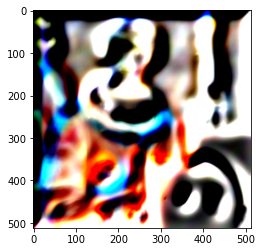

In [136]:
plt.imshow(res.as_array())
plt.show()